In [1]:
%matplotlib widget

from iris_raster import IrisRaster
import glob
import numpy as np
import matplotlib.pyplot as plt
from models import Models
import os
from Functions.utilities import get_extent
from astropy.wcs import WCS
import astropy.units as u
from astropy.coordinates import SkyCoord, SpectralCoord
from sunpy.coordinates import frames
import time
# from ndcube import NDCube
from matplotlib.colors import TwoSlopeNorm
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.constants import c
from Functions.sunpy_map_cut import sunpy_map_cut
from astropy.io import fits
from sunpy.map import Map as sm
from utilities import utilities as utils
import multiprocessing as mp
from tqdm import tqdm
from sunpy.time import TimeRange
import datetime


In [2]:
def slice_spectralcube_by_spatial_pixel(spectral_cube,row_l,row_u,col_l,col_u):
    """
    row_l is lower row index in spatial coord
    """
    D2 = spectral_cube[col_l:col_u+1,row_l:row_u+1]

    return D2

In [3]:
hdu_index = 1
raster_file = "./../iris_obj/data_aligned/D044/RASTER_FILES/iris_l2_20160319_145728_3623010639_raster_t000_r00000.fits"
# fit_file = "./FITTING/CII_1394/Gaussian_Linear_Bg/iris_l2_20160319_145728_3623010639_raster_t000_r00000.npy"
aia_171_file = "./../iris_obj/data_aligned/D044/171/2016-03-19T14_59_23.fits"
# aia_193_file = "./data_aligned/D044/193/2016-03-19T14_59_42.fits"
# hmi_file = "./data_aligned/D044/HMI/2016-03-19T14_59_44.fits"
# sji_file = "./data_aligned/D044/SJI_FILES/2016-03-19T14_59_24.fits"
# red_chisq_file = './FITTING/CII_1394/red_chisq_computed/iris_l2_20160319_145728_3623010639_raster_t000_r00000.npy'
error_file = f"./../iris_obj/Errors/D044/iris_l2_20160319_145728_3623010639_raster_t000_r00000/ERR_hdu_{hdu_index}.npy"
y0,y1 = 320,400                 # lower and upper limit of the scans to be shown in the paper
print(os.path.isfile(error_file))



True


Getting Background


In [4]:
BG_ext = [12,23,345,352]        # ***** Extension for the background in arcsec.


This is C II 1336 line.
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Mean wavelength for background fitting= 1334.5316730546072
Reduced chi square for background fitting= 3.1625034693224436
Reduced chi square for background fitting_computed= 3.1625034693224436
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


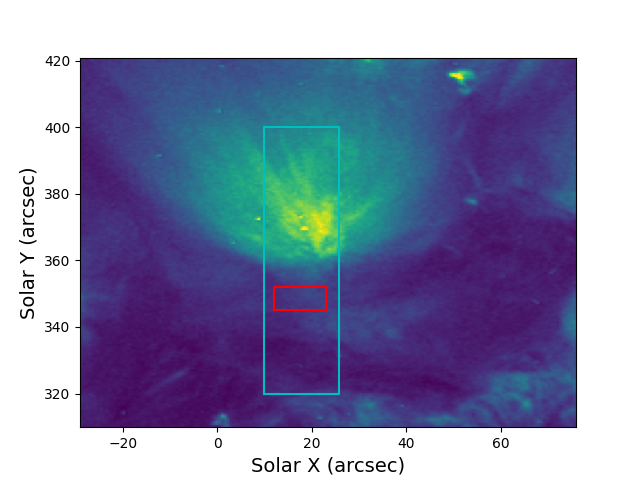

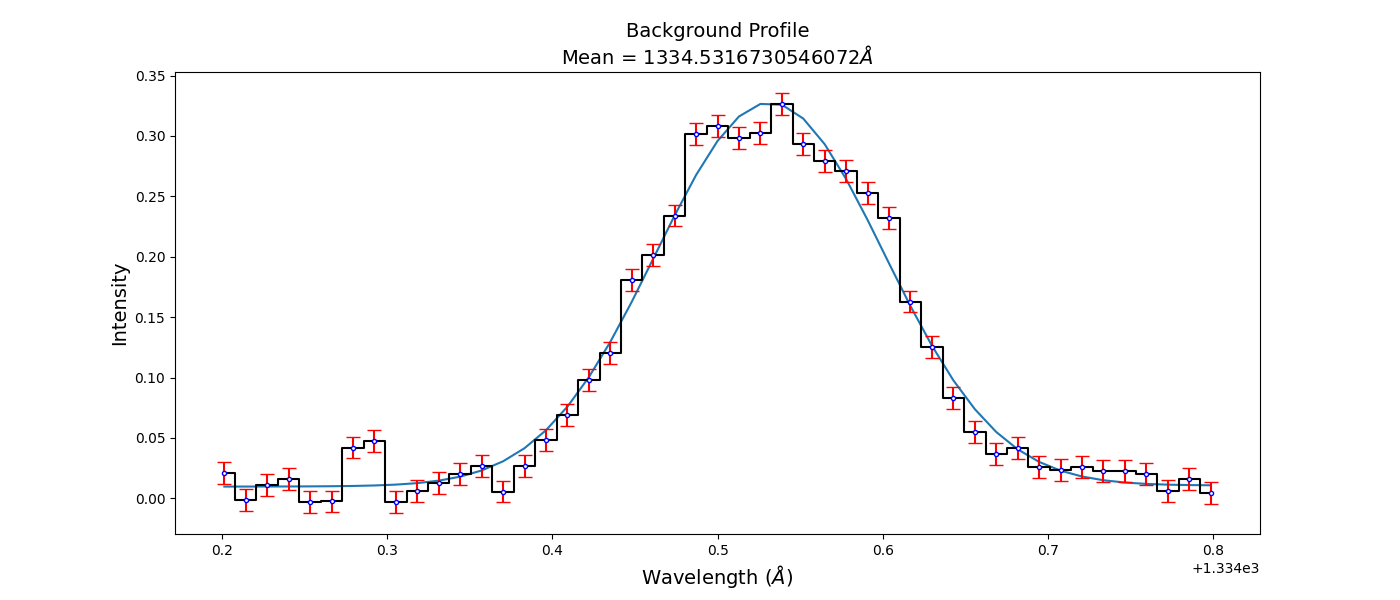

In [5]:
with IrisRaster(raster_file) as raster:


    wrange = raster.get_wrange('CII_1334')
    m = raster.get_spectroheliogram(hdu_index,1334.53)  # It is only for finding background corner indices!

    data,hd = raster.get_data_header(hdu_index,print_line=True)

    ERR = np.load(error_file)
    coordinate_lower = SkyCoord(BG_ext[0]*u.arcsec,BG_ext[2]*u.arcsec,frame=m.coordinate_frame)
    coordinate_upper = SkyCoord(BG_ext[1]*u.arcsec,BG_ext[3]*u.arcsec,frame=m.coordinate_frame)

    col_l,row_l = m.world_to_pixel(coordinate_lower)
    col_u,row_u = m.world_to_pixel(coordinate_upper)

    col_l,col_u,row_l,row_u = int(np.rint(col_l.value)),int(np.rint(col_u.value)),int(np.rint(row_l.value)),int(np.rint(row_u.value))

    bg_cube = slice_spectralcube_by_spatial_pixel(data,row_l,row_u,col_l,col_u)
    bg_err = slice_spectralcube_by_spatial_pixel(ERR,row_l,row_u,col_l,col_u)
    wavelengths = raster.get_wavelengths(hdu_index).value
    fuv_exp_time = raster.get_fuv_exposure_time()       #********
    bg_cube = bg_cube/fuv_exp_time[:,np.newaxis,np.newaxis][col_l:col_u+1]  #**********

    mean_bg_spectra = np.mean(bg_cube,axis=(0,1))
    bg_err_sq = bg_err**2
    mean_bg_err = np.sqrt(np.sum(bg_err_sq,axis=(0,1)))/(bg_err.shape[0]*bg_err.shape[1])


    wavelength_ind = np.logical_and(wavelengths>=wrange[0],wavelengths<=[wrange[1]])
    wavelengths = wavelengths[wavelength_ind]
    mean_bg_spectra = mean_bg_spectra[wavelength_ind]
    mean_bg_err = mean_bg_err[wavelength_ind]

    peak_height_init = float(np.max(mean_bg_spectra))
    ind_peak = np.where(mean_bg_spectra==peak_height_init)[0]
    w_cen = float(wavelengths[ind_peak][0])
    init_value=[peak_height_init,w_cen,0.1,0.0,0.0]
    popt,pcov_false = curve_fit(Models.Gauss1linearbackground,wavelengths,mean_bg_spectra,p0=init_value,sigma=mean_bg_err,absolute_sigma=False)
    popt1,pcov_true = curve_fit(Models.Gauss1linearbackground,wavelengths,mean_bg_spectra,p0=init_value,sigma=mean_bg_err,absolute_sigma=True)
    red_chisq = pcov_false/pcov_true

    G = Models.Gauss1linearbackground(wavelengths,popt[0],popt[1],popt[2],popt[3],popt[4],)
    Mu_bg = popt[1]
    chi_sq2 = (mean_bg_spectra-G)**2/mean_bg_err**2
    red_chisq3 = np.sum(chi_sq2)/(len(mean_bg_spectra)-5)
    print(f"Mean wavelength for background fitting= {Mu_bg}")
    print(f"Reduced chi square for background fitting= {red_chisq[0][0]}")
    print(f"Reduced chi square for background fitting_computed= {red_chisq3}")

    #   all the plots are below
    fig_spectra_bg = plt.figure(figsize=(14,6))
    ax_spectr_bg = fig_spectra_bg.add_subplot(1,1,1)

    ax_spectr_bg.set_xlabel('Wavelength ($\AA$)',fontsize=14,fontweight='medium')
    ax_spectr_bg.set_ylabel('Intensity',fontsize=14,fontweight='medium')
    ax_spectr_bg.plot(wavelengths,G)
    ax_spectr_bg.errorbar(
        wavelengths,
        mean_bg_spectra,
        yerr=mean_bg_err,
        drawstyle='steps-mid',
        color='black',
        capsize=5,             # Size of error bar caps
        capthick=1,            # Thickness of caps
        ecolor='red',         # Color of error bars
        marker='o',            # Add markers at data points
        markersize=3,
        markerfacecolor='white',
        markeredgecolor='blue',
        label='Data with Errors'
        )
    ax_spectr_bg.set_title(f"Background Profile\nMean = {Mu_bg}$\\AA$",fontsize=14)

    bl = [float(m.bottom_left_coord.Tx.value),float(m.bottom_left_coord.Ty.value)]
    tr = [float(m.top_right_coord.Tx.value),float(m.top_right_coord.Ty.value)]

    bg_rect = utils.ext2rect(BG_ext)
    m = sunpy_map_cut(m,[bl[0],y0],[tr[0],y1])

    bl = [float(m.bottom_left_coord.Tx.value),float(m.bottom_left_coord.Ty.value)]
    tr = [float(m.top_right_coord.Tx.value),float(m.top_right_coord.Ty.value)]
    ext_spectrogram = [float(l) for l in get_extent(m)]


    fig2 = plt.figure()
    ax_r = fig2.add_subplot(1,1,1)

    m_171 = sm(aia_171_file)
    im_r = ax_r.imshow(m_171.data,origin="lower",extent=get_extent(m_171),vmin=40,vmax=500,aspect="auto")
    ax_r.plot(utils.ext2rect(ext_spectrogram)[0],utils.ext2rect(ext_spectrogram)[1],'-c')
    ax_r.set_xlabel("Solar X (arcsec)", fontsize=14)
    ax_r.set_ylabel("Solar Y (arcsec)", fontsize=14)
    plt.ticklabel_format(style='plain')    # to prevent scientific notation.

    ax_r.plot(bg_rect[0],bg_rect[1],'-r')

    fig2.savefig("./FIGS/BG/plume_scan_broad.jpeg",dpi=300,bbox_inches="tight")
    fig_spectra_bg.savefig("./FIGS/BG/Background_spectra_C_II1334.jpeg",dpi=300,bbox_inches="tight")

    fig2.savefig("./FIGS/BG/plume_scan_broad.pdf",bbox_inches="tight")
    fig_spectra_bg.savefig("./FIGS/BG/Background_spectra_C_II1334.pdf",bbox_inches="tight")

    plt.show()

Sample fitting

In [6]:
"""
Provided spectral datacube,error,wcs and binning (mxn) ; m pixel along row and n pixel along column; the function will return new datacube, error and wcs.
"""
D = "D044"
m = 2
n = 1
fitting_type = "Gaussian1_Linear_Bg"
line_name = "CII_1334"
file = f"./data_aligned/{D}/RASTER_FILES/iris_l2_20160319_145728_3623010639_raster_t000_r00004.fits"
files = glob.glob(f"./../iris_obj/data_aligned/{D}/RASTER_FILES/*.fits")
files = sorted(files)

for file in files[0:1]:
    print(file)

    file_name = os.path.basename(file).replace(".fits","")
    with IrisRaster(file) as raster:
        # other_files = glob.glob(f"./data_scanwise/{D}/{file_name}/*/*/*.fits")
        # MS = sm(other_files)

        wrange = raster.get_wrange('CII_1334')

        data , err , dummy_raster_2d , wavelength , MS_sub= raster.get_spectral_cube(hdu_index,wrange=wrange,rebinn=[[m,n]])
        print(data.shape)

./../iris_obj/data_aligned/D044/RASTER_FILES/iris_l2_20160319_145728_3623010639_raster_t000_r00000.fits
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
1
(16, 388, 47)


In [7]:
def fit_datacube_gaussian1_with_linear_bg(args):
    """
    data is spectra with wavelength and error all 1d array\n
    i is just to track index to re assign array of popt etc!\n
    """
    data,err,wavelength,i = args
    
    data = np.array(data)
    err = np.array(err)
    wavelength = np.array(wavelength)

        
    w_cen = 1334.53
    peak_height_init = 1
    init_value=[peak_height_init,w_cen,0.1,0.1,0.1]

    bnd_l = [0,1334.35,0,-np.inf,-np.inf]
    bnd_u = [np.inf,1334.75,0.2,np.inf,np.inf]
    bnd = (bnd_l,bnd_u)

    try:
        popt,_ = curve_fit(Models.Gauss1linearbackground,wavelength,data,p0=init_value,sigma=err,bounds=bnd,absolute_sigma=True,maxfev=10000)

        G = Models.Gauss1linearbackground1(wavelength,popt)
        chi_sq = (data-G)**2/err**2
        red_chisq = np.sum(chi_sq)/(len(data)-5)
    except:
        popt = np.array([np.nan]*5)
        red_chisq = np.nan


    return wavelength,data,popt,red_chisq,i


resampling other aia files



In [8]:
"""
Provided spectral datacube,error,wcs and binning (mxn) ; m pixel along row and n pixel along column; the function will return new datacube, error and wcs.
"""

from physics import get_flux_gaussian , get_wavelength2dopplershift , get_fwhm , get_nonthermal_vel_SiIV1394
import astropy.units as u

D = "D044"
m = 2
n = 1

files = glob.glob(f"./../iris_obj/data_aligned/{D}/RASTER_FILES/*.fits")
files = sorted(files)

for file in files[0:1]:
    file_name = os.path.basename(file).replace(".fits","")

    target_dir_fit = f"./FITTING/{line_name}/{fitting_type}/m_{m}-n_{n}/{file_name}"
    if not os.path.isdir(target_dir_fit):
        os.makedirs(target_dir_fit)

    with IrisRaster(file) as raster:
        other_files = glob.glob(f"./../iris_obj/data_scanwise/{D}/{file_name}/*/*/*.fits")
        MS = sm(other_files)

        wrange = raster.get_wrange('CII_1334')

        data , err , dummy_raster_2d , wavelength , MS_sub= raster.get_spectral_cube(hdu_index,wrange=wrange,rebinn=[[m,n],MS])
        dummy_raster_path = os.path.join(target_dir_fit,"dummy_raster_2d.fits")
        wavelength_path = os.path.join(target_dir_fit,"wavelength.npy")
        dummy_raster_2d.save(dummy_raster_path,overwrite=True)

        for f,m_s in zip(other_files,MS_sub):
            target_path = f.split('/')[::-1][0:5][::-1]
            target_path = "/".join(target_path)
            target_path = os.path.join(f"./data_scanwise_m-{m}_n-{n}",target_path)
            target_dir = os.path.dirname(target_path)
            os.makedirs(target_dir,exist_ok=True)
            m_s.save(target_path,overwrite=True)



INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
2
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Mi

In [10]:
from physics import get_nonthermal_vel_CII1334
from physics import get_flux_gaussian , get_wavelength2dopplershift , get_fwhm
import astropy.units as u

In [12]:
"""
Provided spectral datacube,error,wcs and binning (mxn) ; m pixel along row and n pixel along column; the function will return new datacube, error and wcs.
"""



D = "D044"
m = 2
n = 1
fitting_type = "Gaussian1_Linear_Bg"
line_name = "CII_1334"
file = f"./data_aligned/{D}/RASTER_FILES/iris_l2_20160319_145728_3623010639_raster_t000_r00004.fits"
files = glob.glob(f"./../iris_obj/data_aligned/{D}/RASTER_FILES/*.fits")
files = sorted(files)

for file in files[1:]:
    file_name = os.path.basename(file).replace(".fits","")

    target_dir_fit = f"./FITTING/{line_name}/{fitting_type}/m_{m}-n_{n}/{file_name}"
    if not os.path.isdir(target_dir_fit):
        os.makedirs(target_dir_fit)

    with IrisRaster(file) as raster:
        # other_files = glob.glob(f"./../iris_obj/data_scanwise/{D}/{file_name}/*/*/*.fits")
        # MS = sm(other_files)

        wrange = raster.get_wrange('CII_1334')

        data , err , dummy_raster_2d , wavelength , MS_sub= raster.get_spectral_cube(hdu_index,wrange=wrange,rebinn=[[m,n]])
        dummy_raster_path = os.path.join(target_dir_fit,"dummy_raster_2d.fits")
        wavelength_path = os.path.join(target_dir_fit,"wavelength.npy")
        dummy_raster_2d.save(dummy_raster_path,overwrite=True)
        np.save(wavelength_path,np.array(wavelength),allow_pickle=True)

        s = data.shape
        data_resampled = data.reshape((s[0]*s[1],s[2]))
        err_resampled = err.reshape((s[0]*s[1],s[2]))
        
        data_arr = np.zeros(data_resampled.shape)
        popt_arr = np.zeros((data_resampled.shape[0],)+(5,))
        red_chisq_arr = np.array([0.0] * data_resampled.shape[0])
        flux_arr = np.array([0.0] * data_resampled.shape[0])
        dopplershift_arr = np.array([0.0] * data_resampled.shape[0])
        fwhm_arr = np.array([0.0] * data_resampled.shape[0])


        zipped_args = list(
            zip(
                data_resampled.tolist(),
                err_resampled.tolist(),
                [wavelength]*err_resampled.shape[0],
                list(range(err_resampled.shape[0]))
                )
            )

        with tqdm(total=len(zipped_args),desc="processing") as pbar:
            for j in range(len(zipped_args)):
                _,_,popt,red_chisq,i = fit_datacube_gaussian1_with_linear_bg(zipped_args[j])
                
                flux = get_flux_gaussian(popt[0],popt[2])
                fwhm = get_fwhm(popt[2]*u.angstrom,1334.53*u.angstrom)
                dopplershift = get_wavelength2dopplershift(popt[1]*u.angstrom,1334.53*u.angstrom)

                # data_arr[j] = data
                popt_arr[j] = popt
                red_chisq_arr[j] = red_chisq
                flux_arr[j] = flux
                fwhm_arr[j] = fwhm
                dopplershift_arr[j] = dopplershift
                pbar.update()

        popt_arr = popt_arr.reshape(s[0:2]+popt_arr.shape[1:])
        red_chisq_arr = red_chisq_arr.reshape(s[0:2])
        flux_arr = flux_arr.reshape(s[0:2])
        dopplershift_arr = dopplershift_arr.reshape(s[0:2])
        fwhm_arr = fwhm_arr.reshape(s[0:2])
        non_th_vel_arr = get_nonthermal_vel_CII1334(fwhm_arr)


        data_arr_path = os.path.join(target_dir_fit,"data.npy")
        popt_arr_path = os.path.join(target_dir_fit,"popt.npy")
        red_chisq_arr_path = os.path.join(target_dir_fit,"red_chisq.npy")
        err_arr_path = os.path.join(target_dir_fit,"err.npy")
        flux_arr_path = os.path.join(target_dir_fit,"flux.npy")
        dopplershift_arr_path = os.path.join(target_dir_fit,"dopplershift.npy")
        fwhm_arr_path = os.path.join(target_dir_fit,"fwhm.npy")
        non_th_vel_arr_path = os.path.join(target_dir_fit,"non_th_vel.npy")


        np.save(data_arr_path,data,allow_pickle=True)
        np.save(popt_arr_path,popt_arr,allow_pickle=True)
        np.save(red_chisq_arr_path,red_chisq_arr,allow_pickle=True)
        np.save(err_arr_path,err,allow_pickle=True)
        np.save(flux_arr_path,flux_arr,allow_pickle=True)
        np.save(dopplershift_arr_path,dopplershift_arr,allow_pickle=True)
        np.save(fwhm_arr_path,fwhm_arr,allow_pickle=True)
        np.save(non_th_vel_arr_path,non_th_vel_arr,allow_pickle=True)


    time.sleep(5)
    print(f"{file} done!")

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
1


processing: 100%|██████████| 6208/6208 [02:01<00:00, 51.02it/s] 


./../iris_obj/data_aligned/D044/RASTER_FILES/iris_l2_20160319_145728_3623010639_raster_t000_r00001.fits done!
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
1


processing: 100%|██████████| 6208/6208 [02:32<00:00, 40.62it/s] 


./../iris_obj/data_aligned/D044/RASTER_FILES/iris_l2_20160319_145728_3623010639_raster_t000_r00002.fits done!
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
1


...

./../iris_obj/data_aligned/D044/RASTER_FILES/iris_l2_20160319_145728_3623010639_raster_t000_r00014.fits done!
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
1


processing: 100%|██████████| 6208/6208 [01:29<00:00, 69.70it/s] 


./../iris_obj/data_aligned/D044/RASTER_FILES/iris_l2_20160319_145728_3623010639_raster_t000_r00015.fits done!
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
1


processing: 100%|██████████| 6208/6208 [01:15<00:00, 82.70it/s] 


./../iris_obj/data_aligned/D044/RASTER_FILES/iris_l2_20160319_145728_3623010639_raster_t000_r00016.fits done!
